In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:

from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename, encoding='latin1')

print(df.head())

Saving Sample - Superstore (1).csv to Sample - Superstore (1).csv
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region     

In [10]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [11]:

df.drop_duplicates(inplace=True)

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

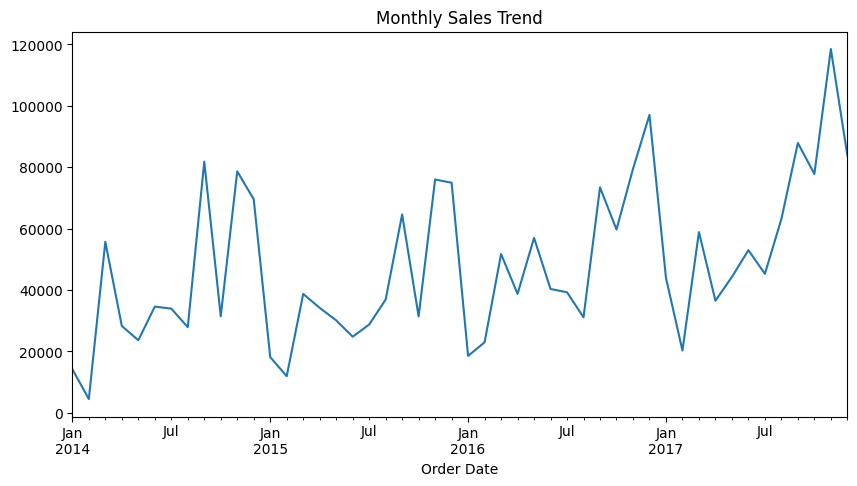

In [13]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

In [14]:

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [15]:

X = df[['Year','Month','Day']]
y = df['Sales']


In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [19]:
predictions = model.predict(X_test)

In [20]:

mae = mean_absolute_error(y_test, predictions)
print(mae)

285.5103717272842


In [21]:
rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)
print(rmse)

768.9605651395613


In [22]:
r2 = r2_score(y_test, predictions)
print(r2)


-0.0010177565361590979


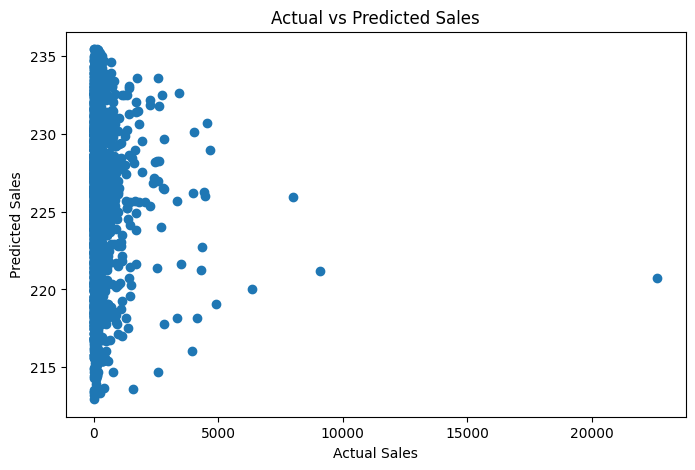

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [24]:
future_data = pd.DataFrame({
    'Year':[2026],
    'Month':[12],
    'Day':[1]
})

future_sales = model.predict(future_data)

print(future_sales)


[225.58883392]


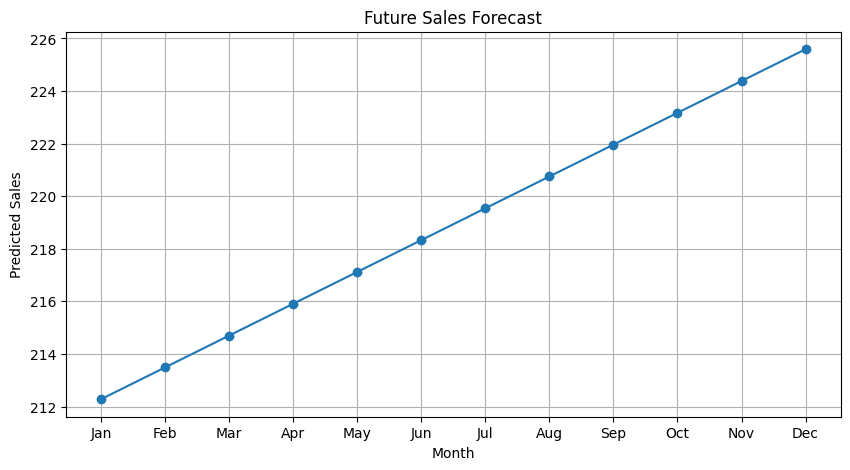

In [25]:
future_months = pd.DataFrame({
    'Year': [2026]*12,
    'Month': list(range(1,13)),
    'Day': [1]*12
})

forecast = model.predict(future_months)

months = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
]

plt.figure(figsize=(10,5))
plt.plot(months, forecast, marker='o')

plt.title('Future Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Predicted Sales')

plt.grid(True)

plt.savefig('future_forecast.png', bbox_inches='tight')

plt.show()